In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

In [5]:
#'yaş', 'sektör tipi', 'Census Bureau bu kişinin kaç kişiyi temsil ettiğini söylüyor.',
#'eğitimseviyesi', 'eğitimseviyesininsayısalkarşılığı',
#'medeni durum', 'meslek', 'aile içindeki rol(husband,wife)', 'ırk', 'cinsiyet',
#'yatırım kazancı', 'yatırım kaybı', 'haftalık çalışma saati', 'doğum ülkesi',
#'gelir'

In [6]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


In [8]:
#problem bu:Bir kişinin geliri 50K üstü mü değil mi?

In [9]:
df.shape

(48842, 15)

In [10]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [11]:
(df == " ? ").sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [12]:
df=df.replace("?",np.nan)

In [13]:
df.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [14]:
pd.crosstab(
    df["workclass"].isnull(),
    df["income"],
    normalize="index"
)

income,<=50K,>50K
workclass,,
False,0.751928,0.248072
True,0.905323,0.094677


In [15]:
pd.crosstab(
    df["occupation"].isnull(),
    df["income"],
    normalize="index"
)

income,<=50K,>50K
occupation,,
False,0.751874,0.248126
True,0.905660,0.094340


In [16]:
pd.crosstab(
    df["native-country"].isnull(),
    df["income"],
    normalize="index"
)

income,<=50K,>50K
native-country,,
False,0.761029,0.238971
True,0.743291,0.256709


In [17]:
missing_cols=["workclass","occupation","native-country"]

In [18]:
df[missing_cols]=df[missing_cols].fillna("Unknown")

In [19]:
df["occupation"].value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Unknown              2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [20]:
for column in missing_cols:
    print(df[column].isnull().sum())

0
0
0


In [21]:
df["income"].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

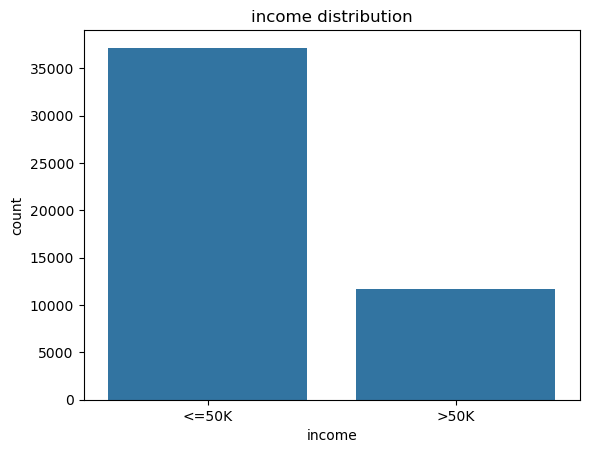

In [22]:
sns.countplot(
    data=df,
    x="income"
)
plt.title("income distribution")
plt.show()

In [23]:
num_cols=['age', 'fnlwgt', 'educational-num',
       'capital-gain', 'capital-loss', 'hours-per-week']
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()


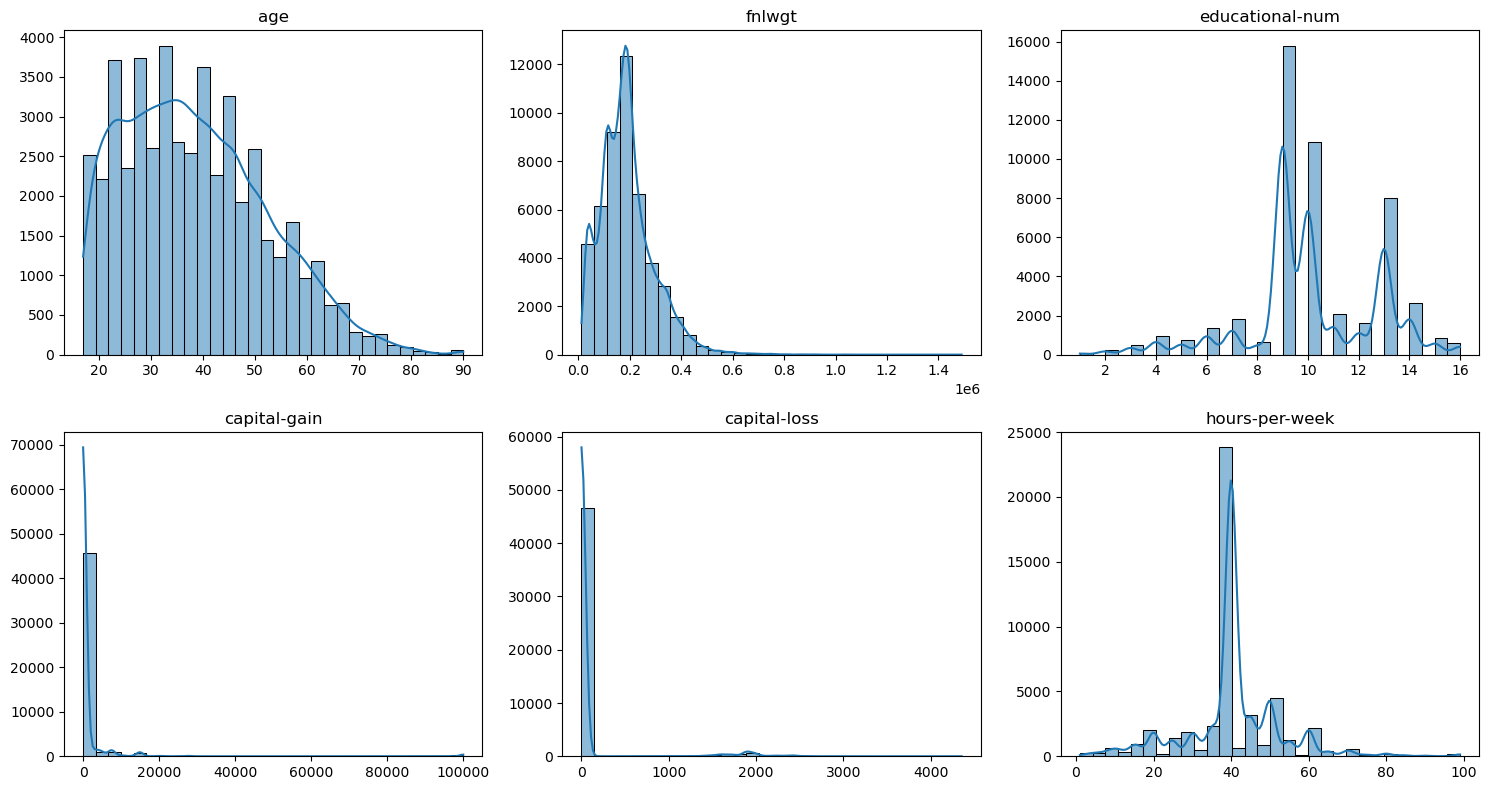

In [24]:
plot_all_histograms(df)

In [25]:
df["capital-gain"].value_counts()

capital-gain
0        44807
15024      513
7688       410
7298       364
99999      244
         ...  
6612         1
1111         1
22040        1
1639         1
2387         1
Name: count, Length: 123, dtype: int64

In [26]:
df["capital-loss"].value_counts()

capital-loss
0       46560
1902      304
1977      253
1887      233
2415       72
        ...  
1539        1
2489        1
2080        1
155         1
2201        1
Name: count, Length: 99, dtype: int64

In [27]:
df["fnlwgt"]=np.log1p(df["fnlwgt"])

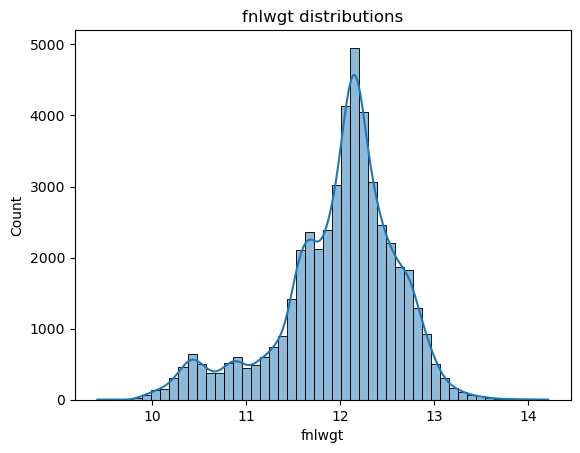

In [28]:
sns.histplot(
    x=df["fnlwgt"],kde=True,bins=50
)
plt.title("fnlwgt distributions")
plt.show()

In [29]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer()
power_cols=["capital-gain","capital-loss"]
df[power_cols]=pt.fit_transform(df[power_cols])

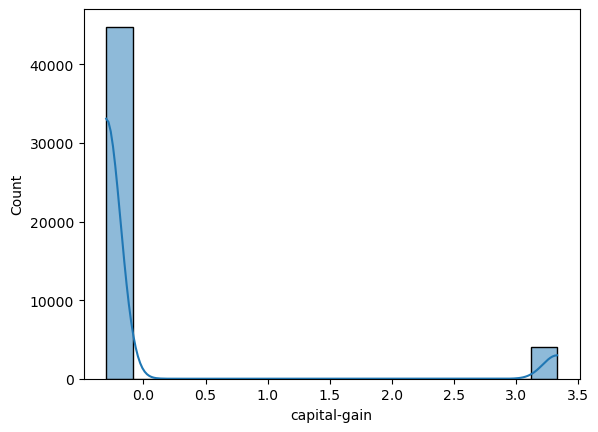

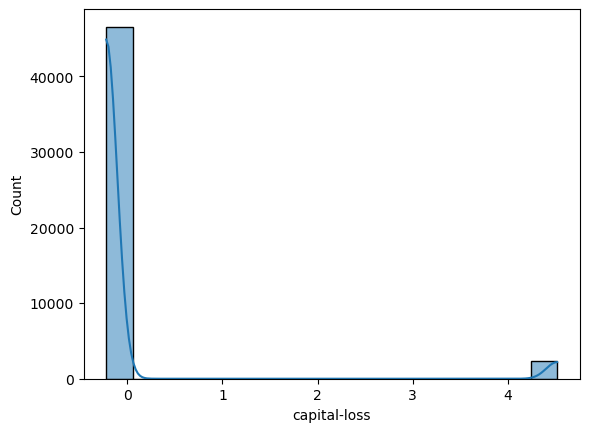

In [30]:
for col in power_cols:
    sns.histplot(
        x=df[col],
        kde=True,
    )
    plt.show()

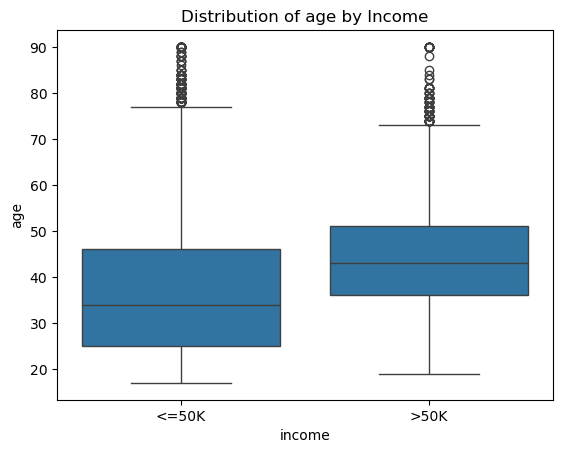

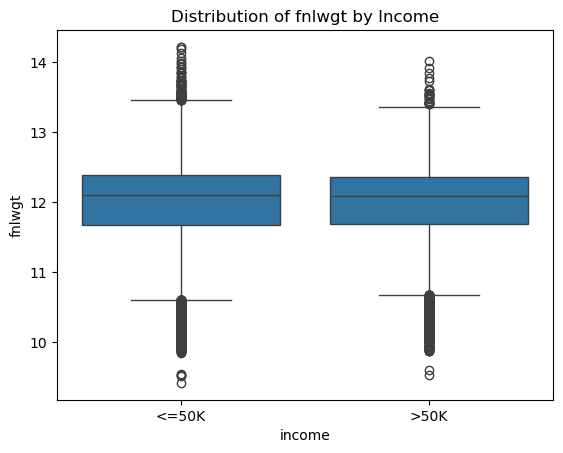

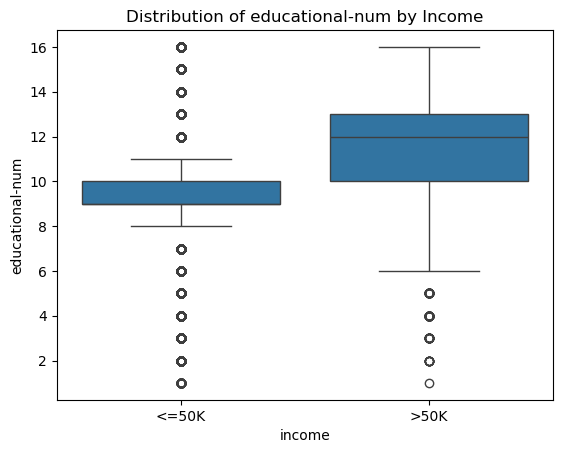

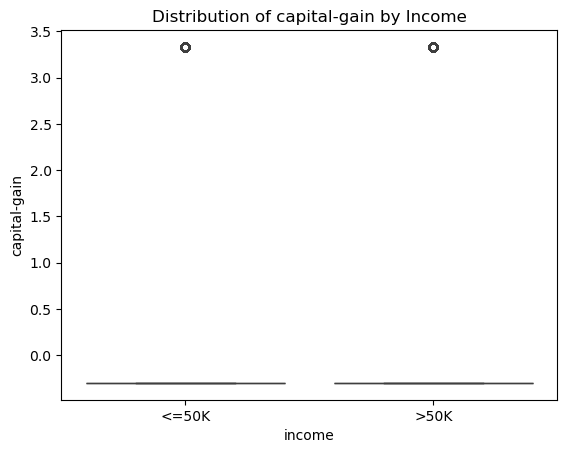

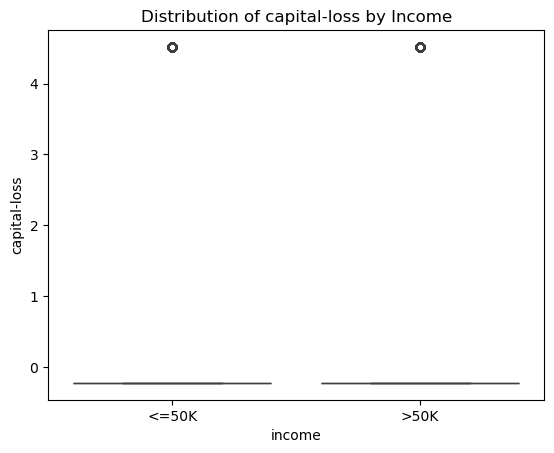

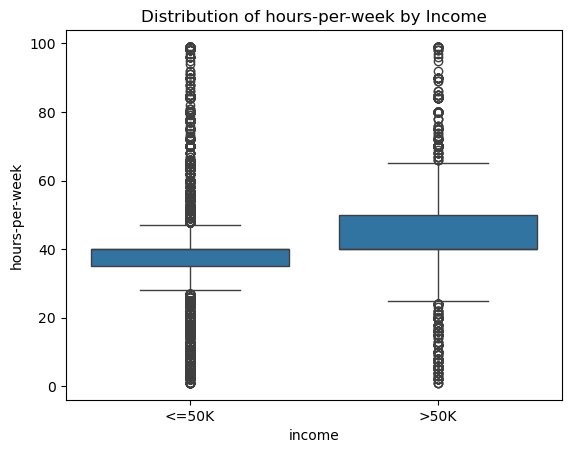

In [31]:

for col in num_cols:
    plt.figure()
    sns.boxplot(
    data=df,
    x="income",
    y=col
)
    plt.title(f"Distribution of {col} by Income")
plt.show()


In [32]:
df["has_capital_gain"] = (df["capital-gain"] > 0).astype(int)
df["has_capital_loss"] = (df["capital-loss"] > 0).astype(int)
pd.crosstab(
    df["has_capital_gain"],
    df["income"],
    normalize="index"
) * 100
pd.crosstab(
    df["has_capital_loss"],
    df["income"],
    normalize="index"
) * 100

income,<=50K,>50K
has_capital_loss,,
0,77.356100,22.643900
1,49.868536,50.131464


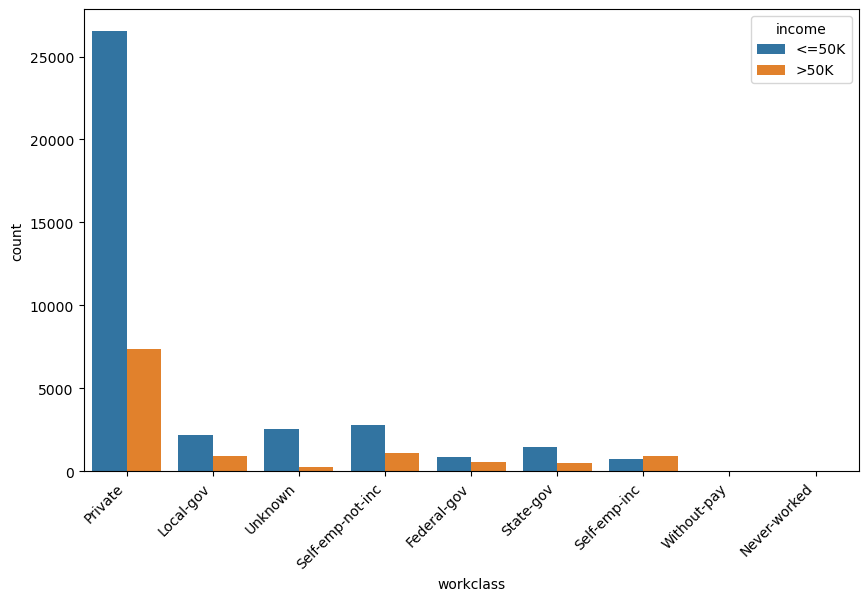

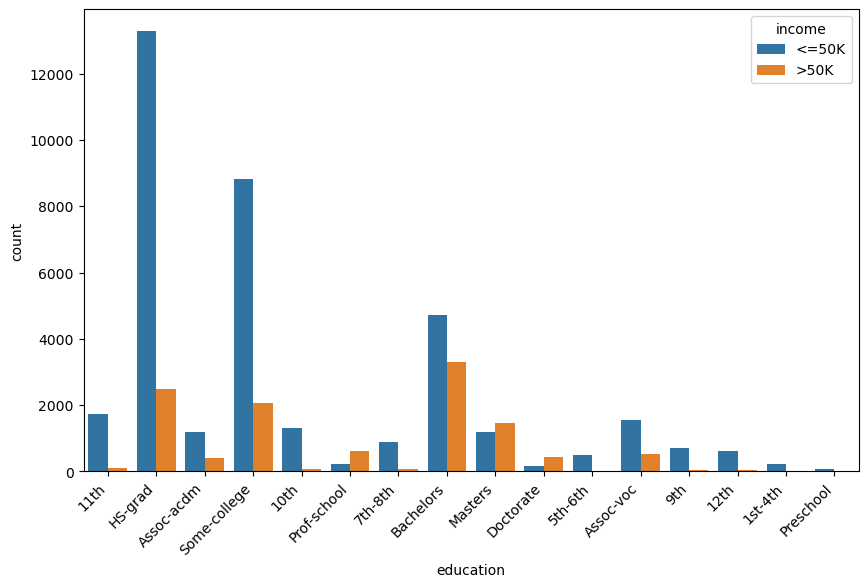

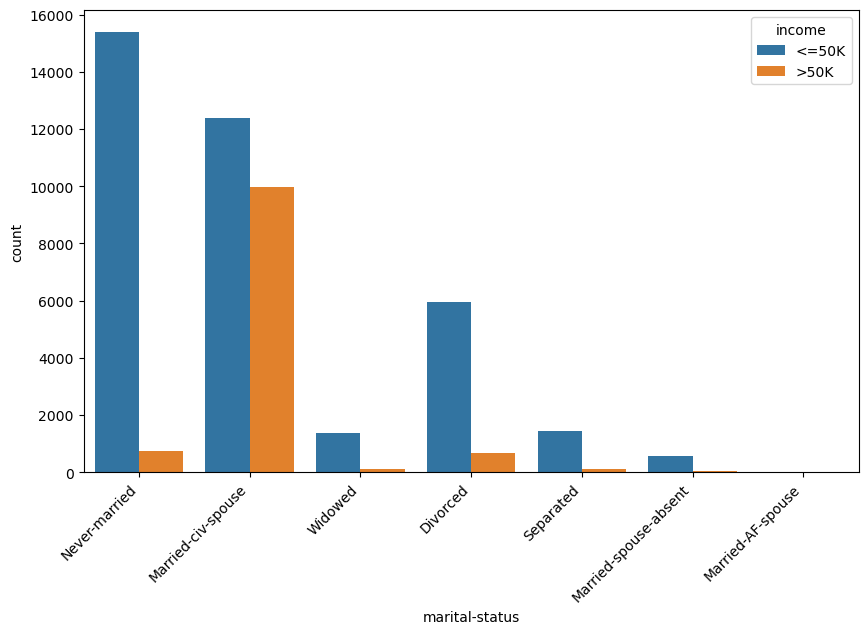

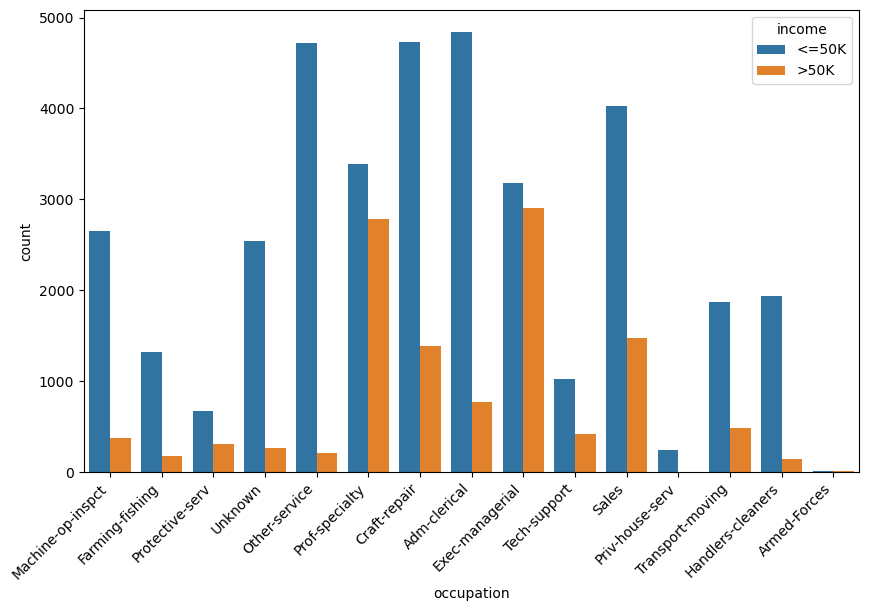

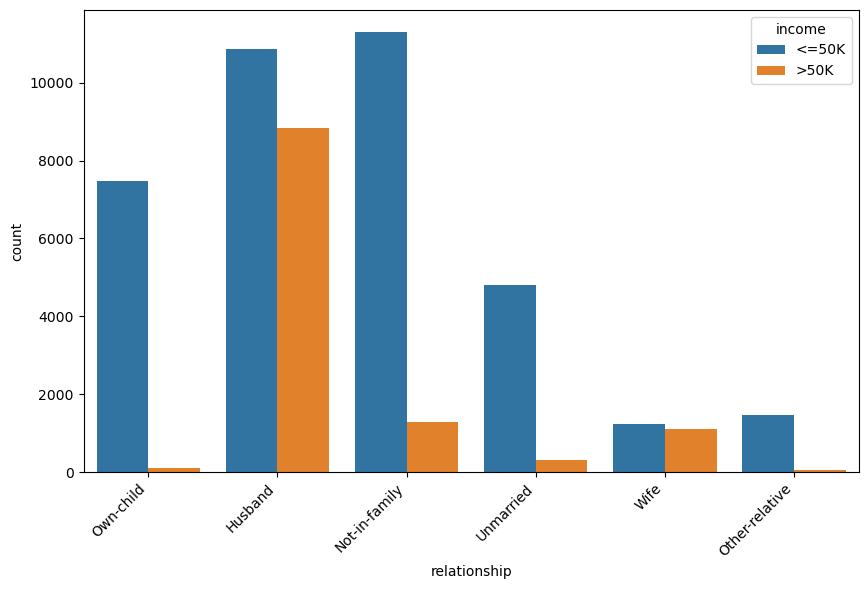

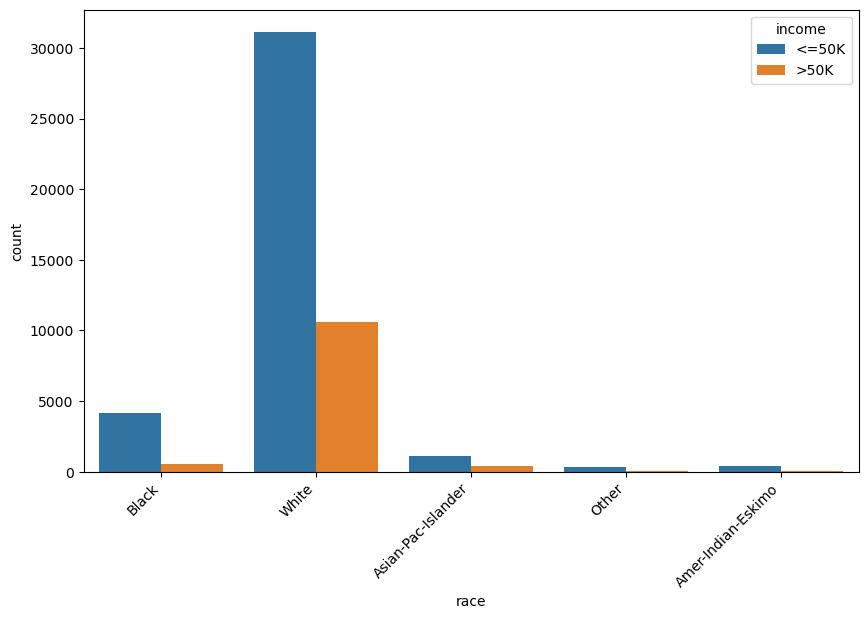

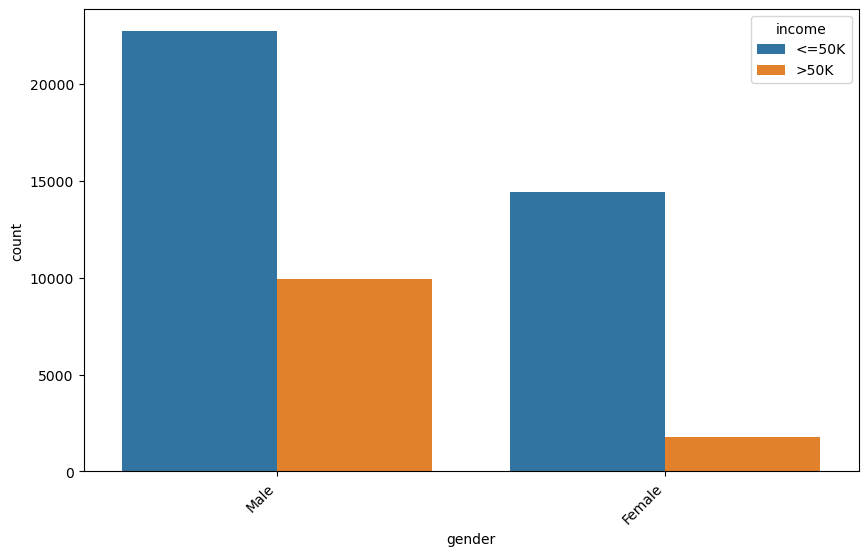

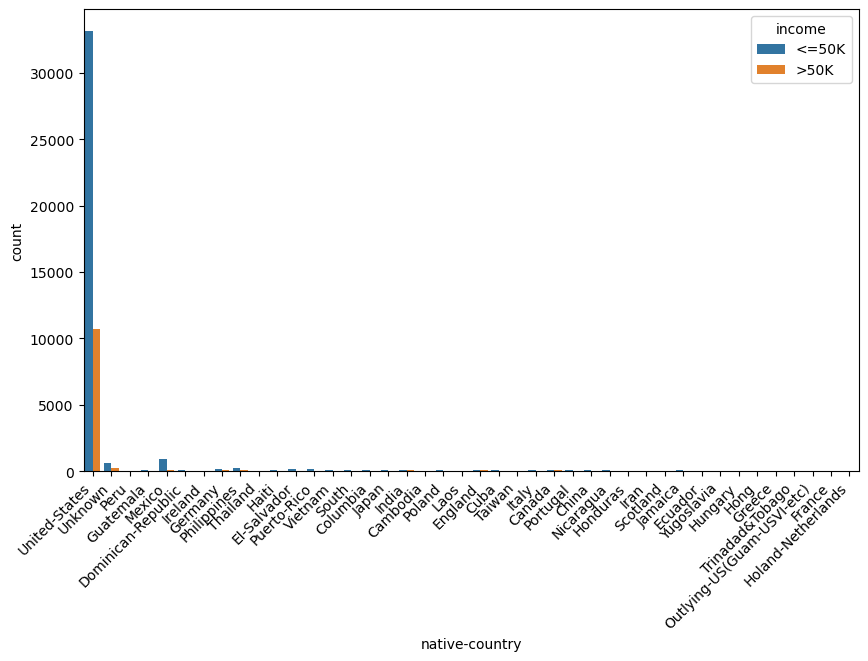

In [33]:
categorical_cols=df[["workclass","education","marital-status","occupation","relationship","race","gender","native-country"]]
for col in categorical_cols:
    plt.figure(figsize=(10,6))
    sns.countplot(    
        data=df,
        x=col,
        hue="income"
    )
    plt.xticks(rotation=45,ha="right")
plt.show()

In [34]:
education_ratio = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
)

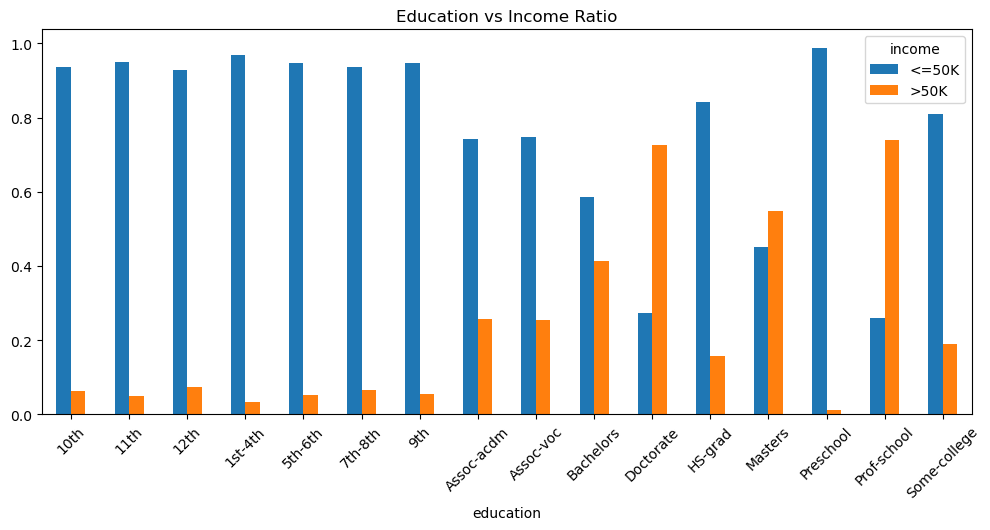

In [35]:
education_ratio.plot(
    kind="bar",
    figsize=(12,5)
)
plt.title("Education vs Income Ratio")
plt.xticks(rotation=45)
plt.show()

In [36]:
unknown_ratio=pd.crosstab(
    df["occupation"],
    df["income"],
    normalize="index"
)
unknown_ratio.loc["Unknown"]

income
<=50K    0.90566
>50K     0.09434
Name: Unknown, dtype: float64

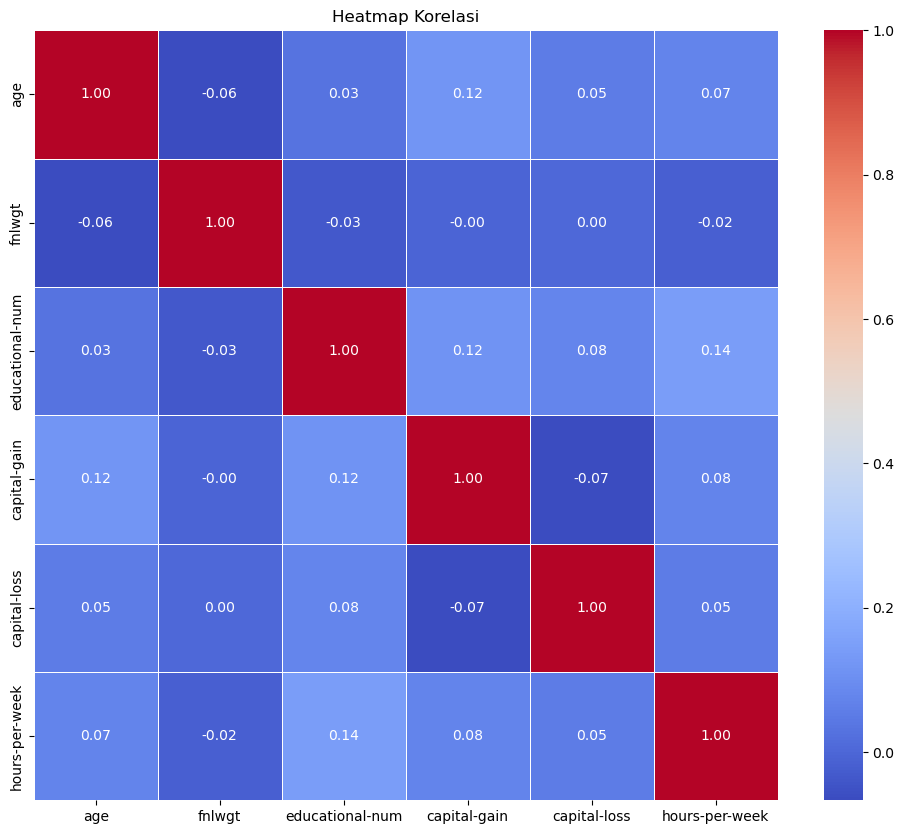

In [37]:
plt.figure(figsize=(12, 10))
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()
    

In [38]:
df.groupby(
    "education"
)["educational-num"].unique()

education
10th             [6]
11th             [7]
12th             [8]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
Assoc-acdm      [12]
Assoc-voc       [11]
Bachelors       [13]
Doctorate       [16]
HS-grad          [9]
Masters         [14]
Preschool        [1]
Prof-school     [15]
Some-college    [10]
Name: educational-num, dtype: object

In [39]:
df.drop("education",axis=1,inplace=True)

In [40]:
df.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,has_capital_gain,has_capital_loss
0,25,Private,12.331837,7,Never-married,Machine-op-inspct,Own-child,Black,Male,-0.300088,-0.221387,40,United-States,<=50K,0,0
1,38,Private,11.405507,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,-0.300088,-0.221387,50,United-States,<=50K,0,0
2,28,Local-gov,12.727696,12,Married-civ-spouse,Protective-serv,Husband,White,Male,-0.300088,-0.221387,40,United-States,>50K,0,0
3,44,Private,11.984952,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,3.332392,-0.221387,40,United-States,>50K,1,0
4,18,Unknown,11.547308,10,Never-married,Unknown,Own-child,White,Female,-0.300088,-0.221387,30,United-States,<=50K,0,0


In [41]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}

    
    #Kodun "tüm datasetlere uygulanabilir" olmasını sağlayan yer burasıdır.
    #Tablodaki metinleri (string/object) atlar ve sadece sayısal (int/float) sütunları listeler.
    
    for col in num_cols:
        #Kodun kalbi olan bu yöntem, veriyi küçükten büyüğe dizer ve 4 parçaya böler.
        #Q1 (%25'lik Dilim): Verinin ilk çeyreği.
        #Q3 (%75'lik Dilim): Verinin üçüncü çeyreği.
        #IQR: Bu iki değerin arasındaki farktır ($IQR = Q3 - Q1$).
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        #Burada "güvenli bölge" oluşturulur. Genellikle threshold (eşik) 1.5 olarak alınır.
        #Lower Bound: Alt sınır. Bunun altındakiler çok küçük uç değerlerdir.
        #Upper Bound: Üst sınır. Bunun üstündekiler çok büyük uç değerlerdir.
        

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]
        #altında ve üstünde kalanları outliers değişkenine ata.
        
        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
        #outlier_count: Kaç tane aykırı değer var?
        #outlier_percentage: Verinin yüzde kaçı aykırı? (Eğer %10'dan fazlaysa veride bir sorun olabilir).
        #Sınırlar: Hangi sayıdan sonrası "aykırı" kabul edildi?
    return pd.DataFrame(outlier_summary)


In [42]:
find_outliers_iqr(df, threshold = 1.5)

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
outlier_count,216.000000,2659.000000,1794.000000,4035.000000,2282.000000,13496.000000
outlier_percentage,0.442242,5.444085,3.673068,8.261332,4.672208,27.631956
lower_bound,-2.000000,10.618792,4.500000,-0.300088,-0.221387,32.500000
upper_bound,78.000000,13.434364,16.500000,-0.300088,-0.221387,52.500000


In [43]:
y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [44]:
X=df.drop("income",axis=1)

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [47]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [48]:
label=LabelEncoder()

In [49]:
X_train["gender"]=label.fit_transform(X_train["gender"])
X_test["gender"]=label.transform(X_test["gender"])

In [50]:
transformer=ColumnTransformer(
    transformers=[
        ("onehot",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        ),
         ["workclass","marital-status","occupation","relationship","race","native-country"]
        )
    ],
    remainder="passthrough"
)

In [51]:
X_train=transformer.fit_transform(X_train)

In [52]:
X_test=transformer.transform(X_test)

In [53]:
feature_names=transformer.get_feature_names_out()

In [54]:
X_train=pd.DataFrame(X_train,columns=feature_names)

In [55]:
X_test=pd.DataFrame(X_test,columns=feature_names)

In [56]:
X_train.head()

,onehot__workclass_Local-gov,onehot__workclass_Never-worked,onehot__workclass_Private,onehot__workclass_Self-emp-inc,onehot__workclass_Self-emp-not-inc,onehot__workclass_State-gov,onehot__workclass_Unknown,onehot__workclass_Without-pay,onehot__marital-status_Married-AF-spouse,onehot__marital-status_Married-civ-spouse,...,onehot__native-country_Yugoslavia,remainder__age,remainder__fnlwgt,remainder__educational-num,remainder__gender,remainder__capital-gain,remainder__capital-loss,remainder__hours-per-week,remainder__has_capital_gain,remainder__has_capital_loss
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,42.0,11.885702,10.0,1.0,-0.300088,-0.221387,40.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,52.0,12.072713,6.0,1.0,-0.300088,-0.221387,35.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,34.0,12.059109,9.0,1.0,-0.300088,-0.221387,40.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,28.0,11.742385,9.0,0.0,-0.300088,-0.221387,40.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,46.0,10.254848,11.0,1.0,-0.300088,-0.221387,50.0,0.0,0.0


In [57]:
X_train.shape

(39073, 87)

In [58]:
X_test.shape

(9769, 87)

In [59]:
X_train.isnull().sum().sum()

0

In [60]:
from sklearn.preprocessing import RobustScaler

In [61]:
scaler=RobustScaler()

In [62]:
X_train=scaler.fit_transform(X_train)

In [63]:
X_test=scaler.transform(X_test)

In [75]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

In [65]:
skf=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [66]:
from sklearn.linear_model import LogisticRegression

In [67]:
lr=LogisticRegression()

In [68]:
lr.fit(X_train,y_train)

LogisticRegression()

In [69]:
y_pred=lr.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [71]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.8492169106356843
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7479
           1       0.72      0.59      0.65      2290

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769

[[6940  539]
 [ 934 1356]]


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier


models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42),
    "KNN":
        KNeighborsClassifier(),
    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42),

    "Random Forest":
        RandomForestClassifier(
            random_state=42),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42),

    "Gradient Boost":
        GradientBoostingClassifier(
            random_state=42),

    "XGBoost":
        XGBClassifier(
            random_state=42)
}

In [73]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score)


for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )


    y_pred = model.predict(
        X_test
    )


    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    recall = recall_score(
        y_test,
        y_pred
    )


    f1 = f1_score(
        y_test,
        y_pred
    )


    print(name)

    print(
        "Accuracy:",
        round(accuracy,3)
    )

    print(
        "Recall:",
        round(recall,3)
    )

    print(
        "F1:",
        round(f1,3)
    )

    print("-"*40)

Logistic Regression
Accuracy: 0.849
Recall: 0.592
F1: 0.648
----------------------------------------
KNN
Accuracy: 0.83
Recall: 0.621
F1: 0.631
----------------------------------------
Decision Tree
Accuracy: 0.814
Recall: 0.628
F1: 0.613
----------------------------------------
Random Forest
Accuracy: 0.857
Recall: 0.631
F1: 0.675
----------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost
Accuracy: 0.867
Recall: 0.632
F1: 0.69
----------------------------------------
Gradient Boost
Accuracy: 0.87
Recall: 0.619
F1: 0.691
----------------------------------------
XGBoost
Accuracy: 0.872
Recall: 0.667
F1: 0.709
----------------------------------------


In [76]:
skf=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [77]:
xgb_model=XGBClassifier(
    random_state=42,eval_metric="logloss"
)

In [78]:
cv_scores=cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

In [79]:
print("CV ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

CV ROC-AUC Scores: [0.91328562 0.92023858 0.91564614 0.92213858 0.92039578]
Mean ROC-AUC: 0.9183409404709055
Std ROC-AUC: 0.0033185452419422384


In [80]:
from sklearn.model_selection import GridSearchCV

In [82]:
params={
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

In [83]:
grid=GridSearchCV(estimator=xgb_model,param_grid=params,cv=skf,scoring="roc_auc",n_jobs=-1)

In [84]:
grid.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='roc_auc')

In [85]:
grid.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

In [86]:
y_pred=grid.predict(X_test)

In [87]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.8751151602006346
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7479
           1       0.77      0.66      0.71      2290

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769

[[7034  445]
 [ 775 1515]]


In [90]:
importance=grid.best_estimator_.feature_importances_

In [91]:
feature_importance=pd.DataFrame(
    {
        "feature":feature_names,
        "importance":importance       
    }
)


In [95]:
feature_importance=feature_importance.sort_values(
    by="importance",
    ascending=False
)

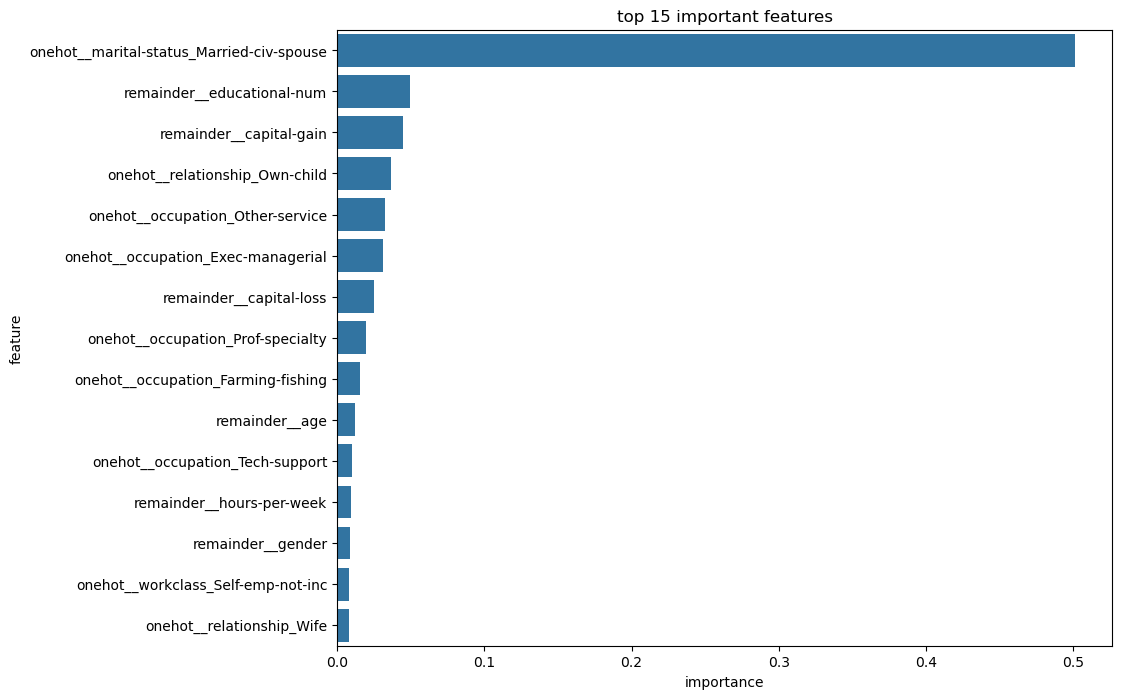

In [96]:
plt.figure(figsize=(10,8))
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)
plt.title("top 15 important features")
plt.show()

In [97]:
X_train = pd.DataFrame(

    X_train,

    columns=feature_names
)

In [98]:
X_test = pd.DataFrame(

    X_test,

    columns=feature_names
)

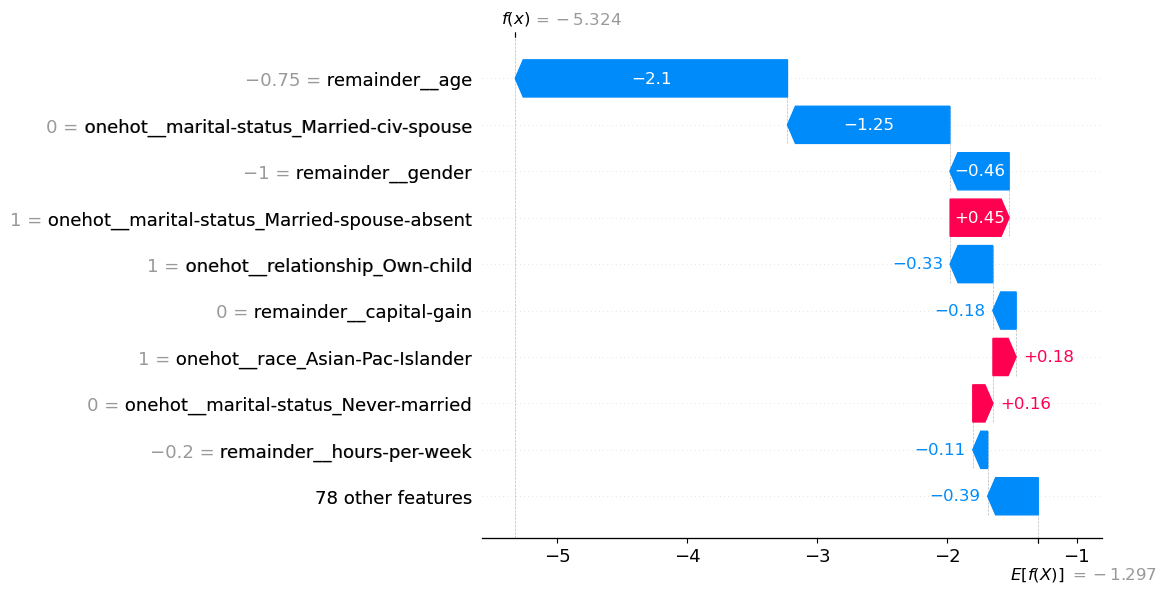

In [99]:
import shap
explainer = shap.TreeExplainer(model)
shap.waterfall_plot(
    explainer(
        X_test[25:26]
    )[0]
)

In [100]:
shap_values = explainer(
    X_test
)

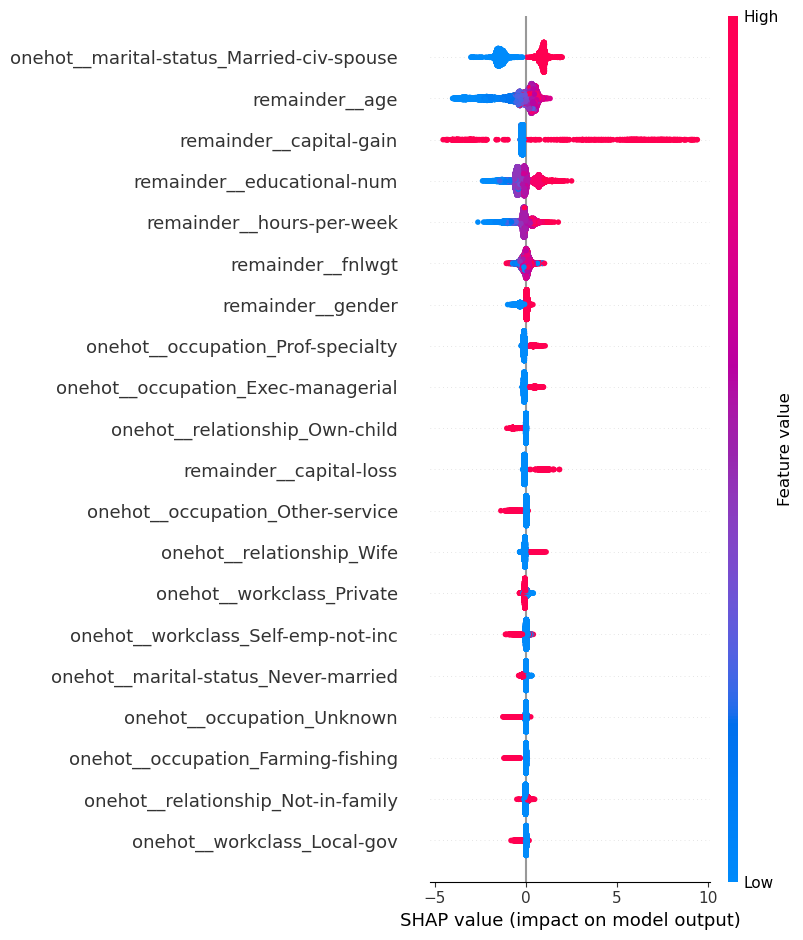

In [101]:
shap.summary_plot(
    shap_values,
    X_test
)